# SVMによる異常検知の実装

ここでは2章で作成したサンプルデータを使用して、SVMによる異常検知をPythonで実装します。

PythonでSVMによる分類を行うには、scikit-learnの[`sklearn.svm.SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)クラスを使用すると便利です。具体的な実装を学習と推論に分けて解説します。

## 学習

次のコードでは、正常と異常のラベルを目的変数としてSVMで学習を行い、決定境界を描画しています（説明変数は5変数のうち`temp1`と`temp2`の2変数を使用）。

In [ ]:
# コード3.1 異常と正常を判別するSVMモデルの学習
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.cm as cm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSVからPandas DataFrameにデータ読込
df = pd.read_csv("./datasets/ch2_dataset_train.csv")

# "temp2","temp1"変数に欠測があるデータを削除
df_dropna = df.dropna(subset=["temp2", "temp1"])
# データをnumpy.ndarrayに変換
X = df_dropna[["temp2", "temp1"]].to_numpy() # 説明変数（2変数のみ使用）
y = df_dropna["label"].to_numpy() # ラベルデータ（目的変数）
# SVMモデル
svm = SVC(C=10, gamma=0.1)
# 標準化とSVMを合わせてパイプライン化する
clf = Pipeline([("scaler", StandardScaler()), ("svm", svm)])
clf.fit(X, y)  # 学習
# 決定境界をプロット
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
disp = DecisionBoundaryDisplay.from_estimator(
    clf, X, response_method="predict",
    xlabel="temp2", ylabel="temp1",
    cmap=cm.gray, alpha=0.5, ax=ax
)
# 散布図を重ねてプロット
sns.scatterplot(data=df_dropna, x="temp2", y="temp1",
                hue="label", palette=["#999999", "#111111"],
                ax=ax
)
plt.show()

SVMは欠測値があるデータには適用できないため、事前に9章で紹介する方法で欠測データを除去または補完する必要があります。またSVMは特徴空間状での距離（ユークリッド距離）に基づくアルゴリズムのため、前処理として標準化を実施する必要があります。

標準化のような前処理を分類モデルと一緒に適用するためには、パイプライン機能（詳細は[こちら](https://qiita.com/c60evaporator/items/7829d8d8322a407d54f1)も参照）を用いると便利です。
上の例では標準化クラス[`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)のインスタンス`scaler`とSVMモデルのインスタンス`svm`を、[`sklearn.pipeline.Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)クラスを用いてパイプライン化しています。

また、決定境界の可視化には[`sklearn.inspection.DecisionBoundaryDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html)クラスを用いています。

図を見ると、カーネルトリックで非線形な決定境界を引けており、またソフトマージンにより一定の誤分類を許容していることがわかります。

## 推論

推論は、上記で学習したモデル（clf）の`predict`メソッドを用いることで実行できます。

In [ ]:
# コード3.2 SVMモデルの推論
# 推論データを読み込み
df_inference = pd.read_csv("./datasets/ch2_dataset_inference.csv")
# "temp2","temp1"変数に欠測があるデータを削除
df_inference_dropna = df_inference.dropna(subset=["temp2", "temp1"])
# データから2変数のみ取り出してnumpy.ndarrayに変換
X_inference = df_inference_dropna[["temp2","temp1"]].to_numpy()
# 学習済みのSVMモデルで推論
y_pred = clf.predict(X_inference)
# 推論結果を表示
print(y_pred)

上の実装例で学習したモデル`clf`は、そのままではPCのメモリ上に保持されるのみで、実行が終わると削除されます。よって学習したモデルを長期間保持したり、学習と推論で実装を分けたい場合は、学習後にモデルをファイルとして保存し、推論時に読み出せる仕組みが必要です。scikit-learnで学習したモデルに関しては、Pythonのオブジェクトをファイル出力できる、Python 標準ライブラリの[pickle](https://docs.python.org/ja/3.13/library/pickle.html)を使用するとよいでしょう。

pickleでモデルを保存するには、学習の実装の最後に以下の記述を追加し、学習済みモデルを`.pkl`ファイル形式で保存します。

In [ ]:
# コード3.3 pickleによるモデルの保存
import pickle
filepath = "./svm_model.pkl" # モデルの保存ファイル名
with open(filepath,"wb") as p: #ファイルを開く
    pickle.dump(clf, p) # pickleでファイルにモデルを保存する

推論の実装では、保存したモデルを`.pkl`ファイルから以下のように読み込みます

In [ ]:
# コード3.4 pickle で保存したモデルの読み込み
filepath = "./svm_model.pkl" # モデルの保存ファイル名
with open(filepath,"rb") as p: #ファイルを開く
    clf = pickle.load(p) # pickle形式ファイルからモデルを読み込み

## 過学習とハイパーパラメータチューニング

ガウスカーネルを用いたSVMには、$\gamma$と$C$という2 つのハイパーパラメータが存在しました。これらのパラメータが決定境界にどのような影響を与えるか、カーネルトリックやソフ
トマージンの原理を交えて見ていきしょう。

以下のコードで、ガウスカーネルの分散の逆数パラメータ$\gamma$（scikit-learnの`SVC`クラスでは`gamma`引数で指定）を変化させた際の決定境界をプロットします。

In [ ]:
# ガウスカーネルの分散の逆数パラメータgammaを変化させた際の決定境界をプロット
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
for i, gamma in enumerate([10, 1, 0.1, 0.01]):
    # SVMを学習
    svm = SVC(C=10, gamma=gamma)
    clf = Pipeline([("scaler", StandardScaler()), ("svm", svm)])  # 標準化とパイプライン化する
    clf.fit(X, y)
    # 決定境界をプロット
    disp = DecisionBoundaryDisplay.from_estimator(
        clf, X, response_method='predict',
        xlabel='temp2', ylabel='temp1',
        cmap=cm.gray, alpha=0.5, ax=axes[i]
    )
    # 散布図を重ねてプロット
    sns.scatterplot(data=df_dropna, x='temp2', y='temp1',
        hue='label', palette=['#999999', '#111111'],
        ax=axes[i]
    )
    axes[i].set_title(f'gamma={gamma}', fontsize=16)
plt.show()

プロットされた図中の$\gamma= 0.1, 1, 10$の比較がわかりやすいですが、$\gamma$が⼤きくなることは、カーネル関数の正規分布の分散が⼩さくなることに相当するため、1点1点に細かくフィットした曲率の⼤きな決定境界が引かれます。細かなフィッティングは一見モデルの性能が高くなるように見えますが、以下の図に示すように、未知データに対する予測性能である**汎化性能**（generalization performance）は、ある程度⼤ざっぱなフィッティングを行った方が高くなります。

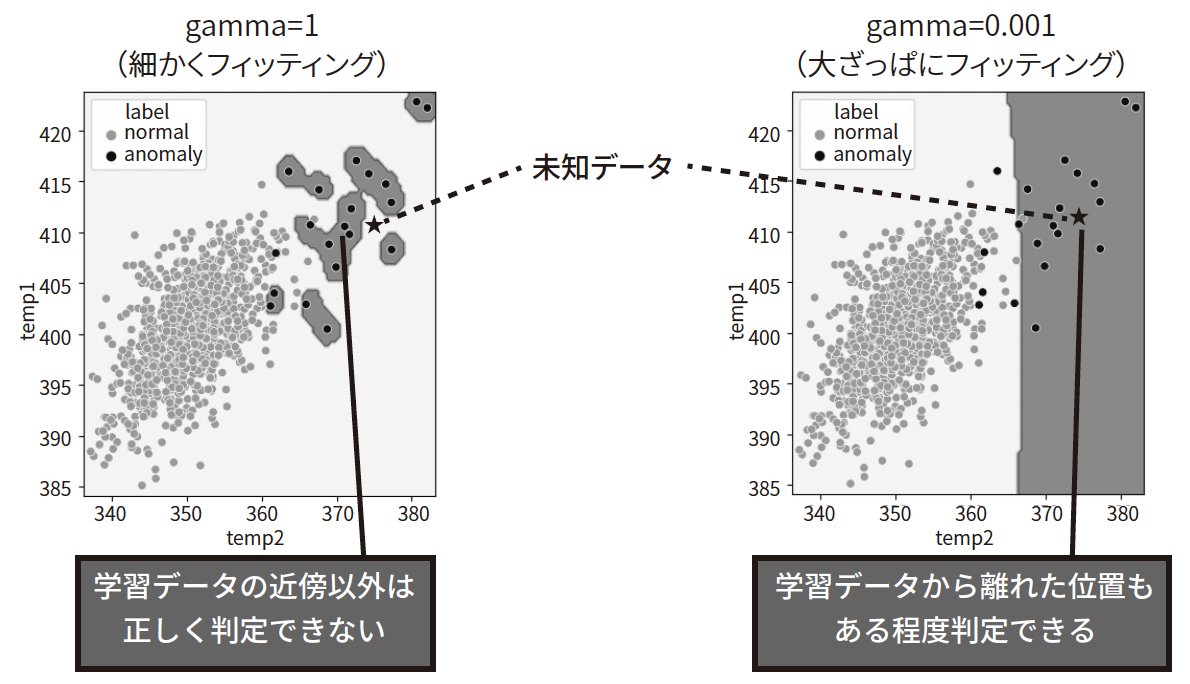

運用時（推論時）にはこのような未知データが入力されるため、1点1点の学習データに細かくフィッティングした状態はむしろ性能を低下させてしまいます。このような学習データに過剰にモデルが適合した状態が、**過学習**（overfitting）です。

次に、もう一つのハイパーパラメータである正則化項パラメータCを変化させて、決定境界をプロットしてみます。

In [ ]:
# 正則化項パラメータCの値を変えて決定境界をプロット
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
for i, C in enumerate([1000, 100, 10, 1]):
    # SVMを学習
    svm = SVC(C=C, gamma=0.1)
    clf = Pipeline([("scaler", StandardScaler()), ("svm", svm)])  # 標準化とパイプライン化する
    clf.fit(X, y)
    # 決定境界をプロット
    disp = DecisionBoundaryDisplay.from_estimator(
        clf, X, response_method='predict',
        xlabel='temp2', ylabel='temp1',
        cmap=cm.gray, alpha=0.5, ax=axes[i]
    )
    # 散布図を重ねてプロット
    sns.scatterplot(data=df_dropna, x='temp2', y='temp1',
        hue='label', palette=['#999999', '#111111'],
        ax=axes[i]
    )
    axes[i].set_title(f'C={C}', fontsize=16)
plt.show()

Cが⼤きいと正則化項の効果が⼩さくなるため、過学習寄りとなって決定境界がいびつな形状となります。一方でC が⼩さいと未学習寄りとなり、決定境界はより滑らかな形状となります。このCに関しても、交差検証を用いて、未知データの性能を最⼤化するよう調整する必要があります。